# Atmos - Exploratory Data Analysis (EDA)

In this notebook, we explore the historical air quality and weather data for Delhi to identify key patterns, seasonal trends, and feature correlations. These insights will drive our feature engineering process for the forecasting model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the dataset
df = pd.read_csv('../data_store/cache/aqi_delhi.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.head()

,station,lat,lon,pm25,pm10,co,no2,so2,o3,aqi
timestamp,,,,,,,,,,
2023-01-01 00:00:00,Anand Vihar,28.6469,77.3164,91.0,135.5,1277.0,55.1,38.3,19.0,201.0
2023-01-01 01:00:00,Anand Vihar,28.6469,77.3164,90.8,134.6,1647.0,60.3,38.3,18.0,500.0
2023-01-01 02:00:00,Anand Vihar,28.6469,77.3164,99.2,145.3,2166.0,67.5,38.3,16.0,229.0
2023-01-01 03:00:00,Anand Vihar,28.6469,77.3164,105.7,154.6,2539.0,72.0,40.3,23.0,251.2
2023-01-01 04:00:00,Anand Vihar,28.6469,77.3164,102.9,150.4,2278.0,66.9,44.7,41.0,241.6


## 1. Time Series Analysis: Seasonal Trends
Let's visualize the PM2.5 concentration over time for a highly polluted station (Anand Vihar). This helps us identify macro-level seasonal patterns.

*Observation: There are massive spikes in PM2.5 during October and November. This strongly suggests we should engineer calendar-based features to account for the stubble burning season and Diwali.*

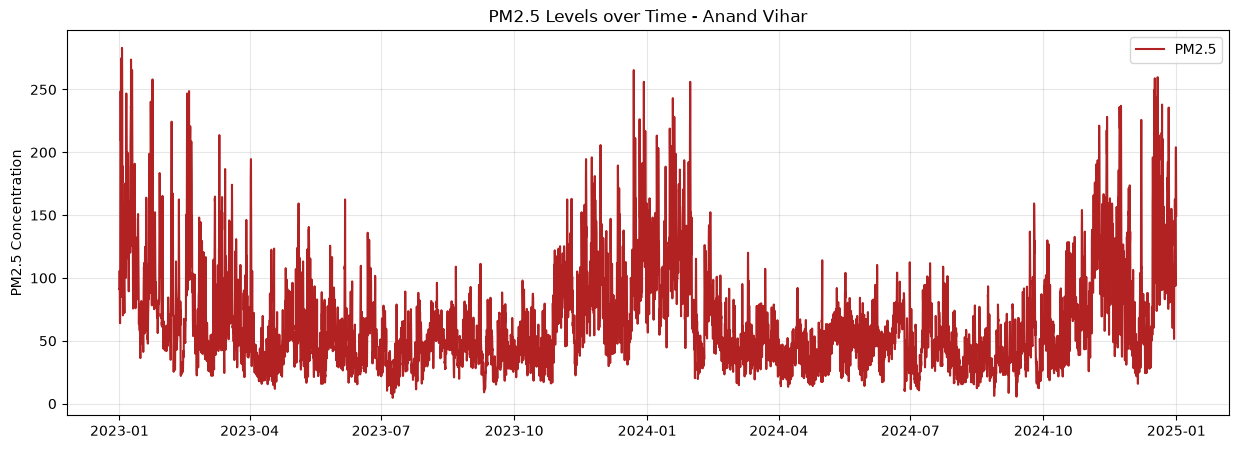

In [2]:
plt.figure(figsize=(15, 5))
anand = df[df['station'] == 'Anand Vihar']
plt.plot(anand.index, anand['pm25'], label='PM2.5', color='firebrick')
plt.title('PM2.5 Levels over Time - Anand Vihar')
plt.ylabel('PM2.5 Concentration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 2. Diurnal Cycle Analysis
Next, we group the data by hour of the day to observe micro-level patterns.

*Observation: We see clear peaks around 9 AM and 8 PM. This correlates strongly with morning and evening traffic rush hours. We will need to encode the time of day (using cyclical sine/cosine transformations) to capture this human activity proxy.*

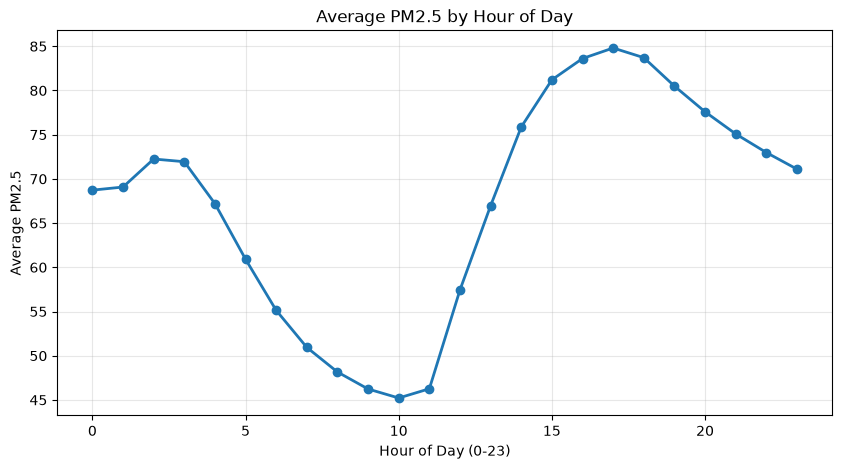

In [3]:
df['hour'] = df.index.hour
hourly_avg = df.groupby('hour')['pm25'].mean()
plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
plt.title('Average PM2.5 by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average PM2.5')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Feature Correlation Matrix
Finally, we analyze how different pollutants and weather variables interact. 

*Observation: Wind speed and temperature show a strong inverse correlation with PM2.5. This confirms that temperature inversions and low wind speeds trap pollutants. We will engineer cross-features (e.g., Temperature / Wind Speed) to help the model capture this dispersion effect.*

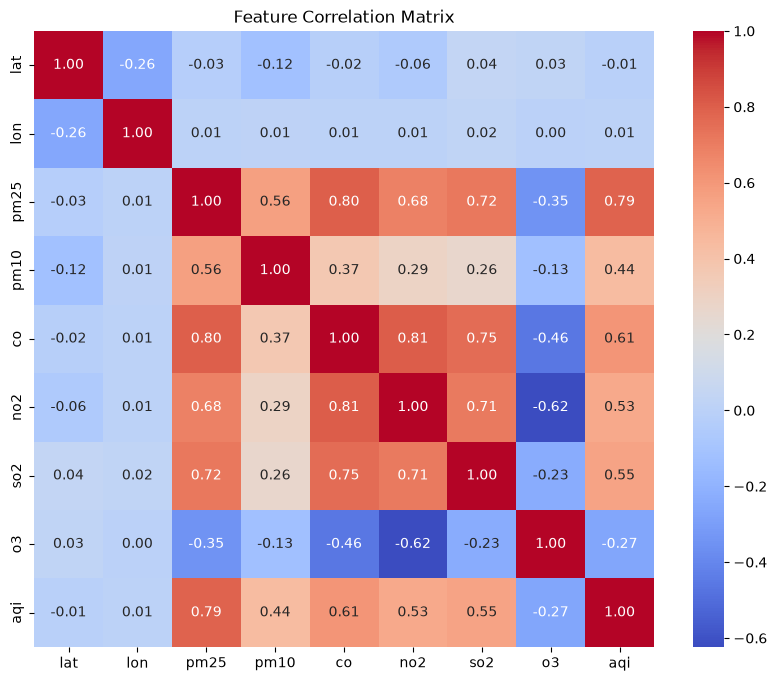

In [4]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()